# Notebook 2 — Classic Computer Vision: Edges, Thresholds & Features

**Digital Humanities · Image Processing for Museums & Cultural Heritage**

Before deep learning (roughly pre-2012), computer vision was built from
hand-designed algorithms. They are still everywhere — fast, explainable,
and they need no training data. In this notebook:

1. **Edge detection** (Sobel, Canny) — analyzing composition and outlines
2. **Thresholding** (Otsu, adaptive) — separating inscriptions/text from background,
   the core of manuscript digitization
3. **Morphological operations** — cleaning up binarized images
4. **Contours** — finding and measuring shapes
5. **Template matching & feature matching (ORB)** — finding one image *inside*
   another, e.g. matching a published detail back to the original artwork

At the end we'll discuss **why these methods hit a wall** — which is exactly
where AI models (Notebook 3) come in.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

DATA = Path("..") / "data" / "raw"
OUT = Path("..") / "outputs"

def load_rgb(name):
    return cv2.cvtColor(cv2.imread(str(DATA / name)), cv2.COLOR_BGR2RGB)

def load_gray(name):
    return cv2.imread(str(DATA / name), cv2.IMREAD_GRAYSCALE)

## 1. Edge detection

An **edge** is a place where brightness changes abruptly. The **Sobel**
operator measures that change in one direction; **Canny** combines both
directions, thins the edges, and keeps only the strong, connected ones.

For art historians: edge maps reveal **composition** — the structural lines
a painter used — independent of color and texture.

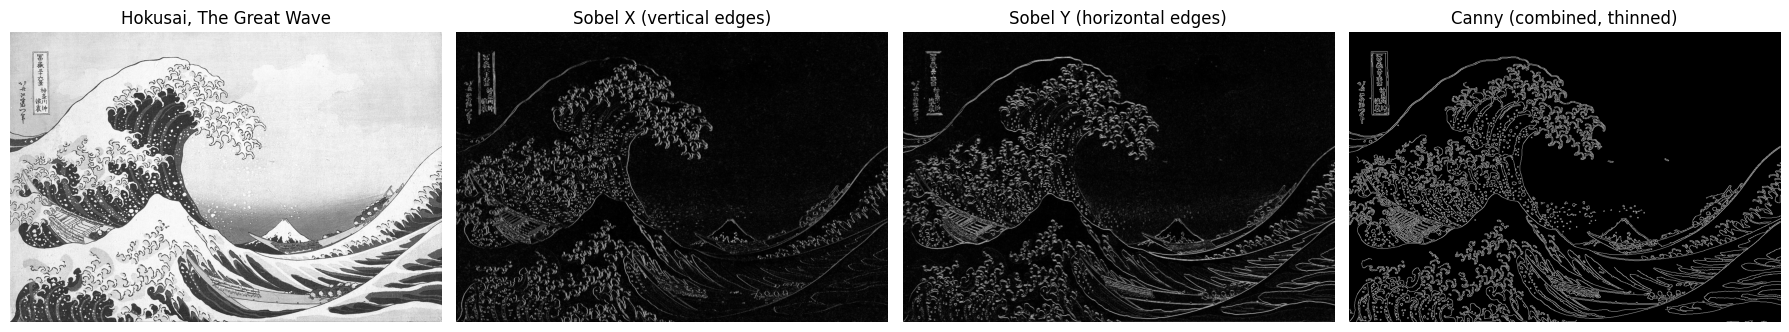

In [2]:
wave = load_gray("great_wave.jpg")

sobel_x = cv2.Sobel(wave, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(wave, cv2.CV_64F, 0, 1, ksize=3)
canny = cv2.Canny(cv2.GaussianBlur(wave, (5, 5), 0), 50, 150)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (im, title) in zip(axes, [
        (wave, "Hokusai, The Great Wave"),
        (np.abs(sobel_x), "Sobel X (vertical edges)"),
        (np.abs(sobel_y), "Sobel Y (horizontal edges)"),
        (canny, "Canny (combined, thinned)")]):
    ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

Try changing the two Canny thresholds (`50, 150`). Low thresholds keep
texture and noise; high thresholds keep only the boldest contours.

## 2. Thresholding: separating figure from ground

Thresholding turns a grayscale image into pure black & white: every pixel
above a cutoff becomes white, the rest black. This is **the** core step in
digitizing manuscripts, inscriptions, and stamps (it's called *binarization*
in the document-analysis world).

- **Global (Otsu)**: one automatic threshold for the whole image
- **Adaptive**: a different threshold for each small neighborhood — essential
  when lighting is uneven (as on a curved stone or a warped page)

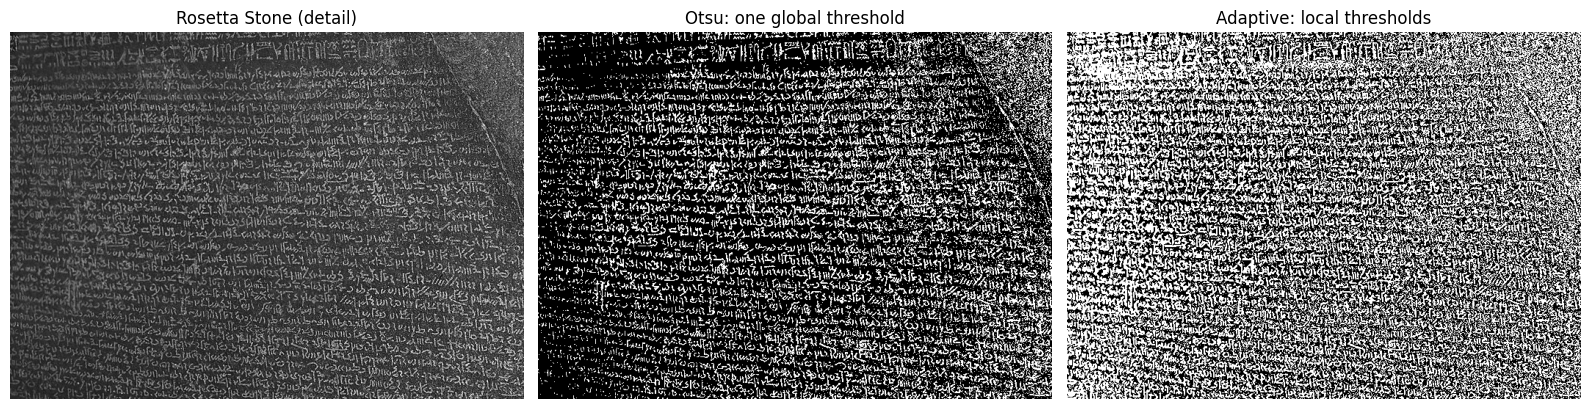

In [3]:
stone = load_gray("rosetta_stone.jpg")
detail = stone[400:900, 300:1000]  # zoom into the inscription

_, otsu = cv2.threshold(detail, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive = cv2.adaptiveThreshold(detail, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, blockSize=31, C=10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (im, title) in zip(axes, [
        (detail, "Rosetta Stone (detail)"),
        (otsu, "Otsu: one global threshold"),
        (adaptive, "Adaptive: local thresholds")]):
    ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

Notice how the adaptive method copes with the uneven lighting across the
stone, where the global threshold loses entire regions. Binarization like
this is the first step before OCR / HTR (handwritten text recognition) —
a major Digital Humanities pipeline of its own.

## 3. Morphological operations: cleaning up

Binary images are often speckled. **Erosion** shrinks white regions,
**dilation** grows them; combined as **opening** (erode→dilate) they remove
small specks, and as **closing** (dilate→erode) they fill small holes.

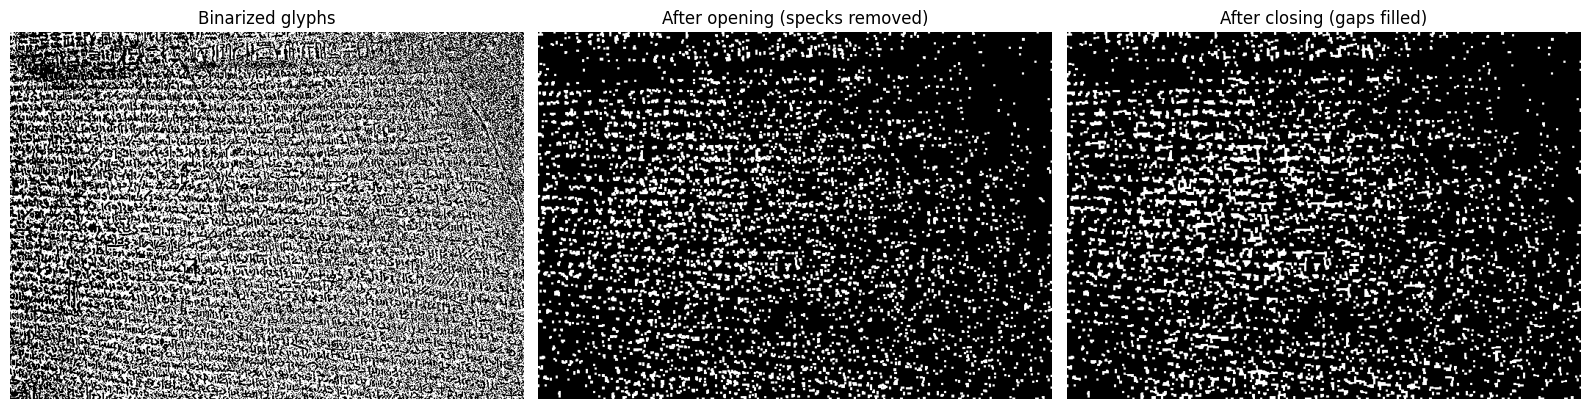

In [4]:
kernel = np.ones((3, 3), np.uint8)
inverted = cv2.bitwise_not(adaptive)           # make the glyphs white
opened = cv2.morphologyEx(inverted, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (im, title) in zip(axes, [
        (inverted, "Binarized glyphs"),
        (opened, "After opening (specks removed)"),
        (closed, "After closing (gaps filled)")]):
    ax.imshow(im, cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Contours: finding and measuring shapes

A **contour** is the outline of a connected white region. Once we have
contours we can count objects, measure their area, and draw boxes around
them — a primitive (but fast and fully explainable) form of object detection.

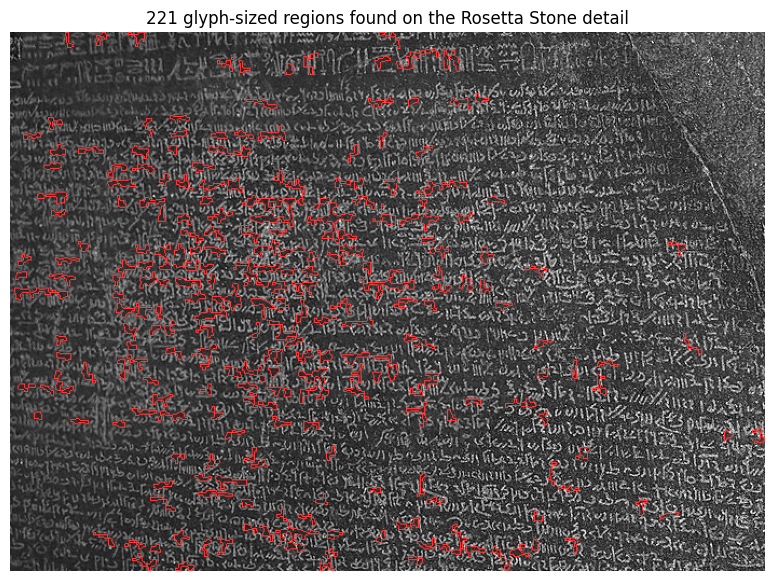

In [5]:
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
big = [c for c in contours if cv2.contourArea(c) > 40]

canvas = cv2.cvtColor(detail, cv2.COLOR_GRAY2RGB)
cv2.drawContours(canvas, big, -1, (255, 60, 60), 1)

plt.figure(figsize=(10, 7))
plt.imshow(canvas); plt.axis("off")
plt.title(f"{len(big)} glyph-sized regions found on the Rosetta Stone detail")
plt.show()

## 5. Finding one image inside another

A very practical museum question: *“This detail was published in a 1960s
catalog — where exactly is it in the painting?”*

**Template matching** slides the detail over the image and measures
similarity at every position. It works — but only if scale and rotation
match exactly.

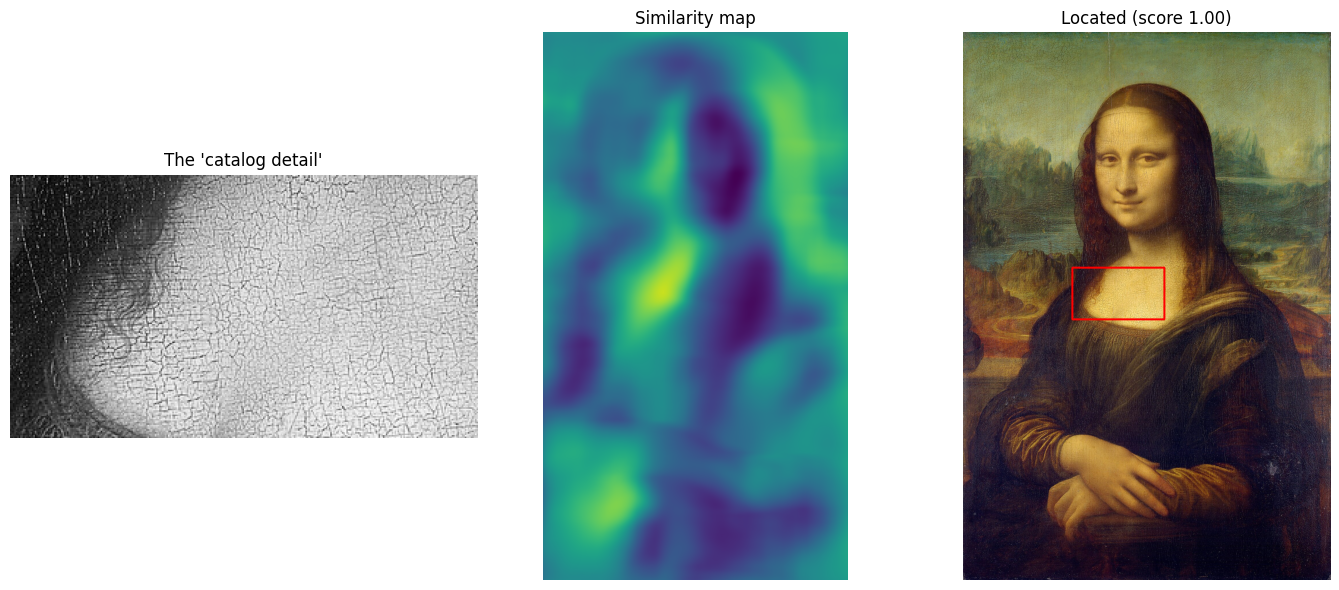

In [7]:
mona = load_rgb("mona_lisa.jpg")
mona_gray = cv2.cvtColor(mona, cv2.COLOR_RGB2GRAY)

template = mona_gray[820:1000, 380:700]   # the famous hands
result = cv2.matchTemplate(mona_gray, template, cv2.TM_CCOEFF_NORMED)
_, score, _, top_left = cv2.minMaxLoc(result)

found = mona.copy()
h, w = template.shape
cv2.rectangle(found, top_left, (top_left[0] + w, top_left[1] + h), (255, 0, 0), 6)

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes[0].imshow(template, cmap="gray"); axes[0].set_title("The 'catalog detail'")
axes[1].imshow(result, cmap="viridis"); axes[1].set_title("Similarity map")
axes[2].imshow(found); axes[2].set_title(f"Located (score {score:.2f})")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

### Feature matching: robust to rotation and scale

Real reproductions are rarely pixel-identical: they're rotated, rescaled,
recolored. **Feature detectors** like ORB find distinctive keypoints
(corners, blobs) and describe their surroundings so they can be matched
across very different versions of the same object.

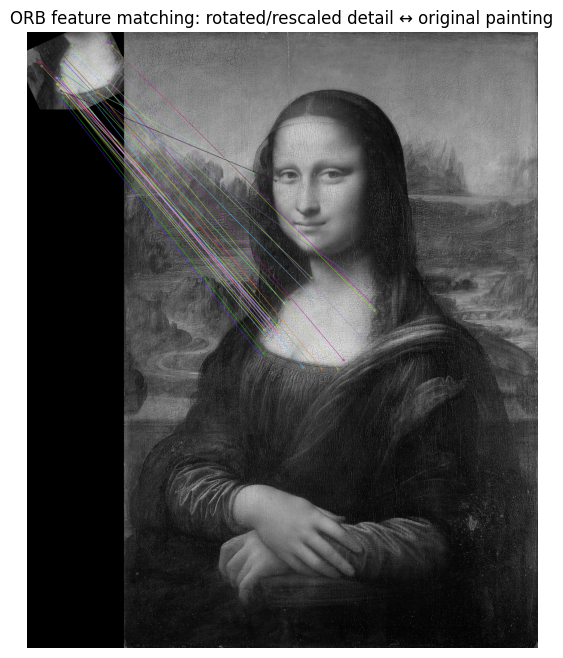

In [8]:
# Simulate a rotated, shrunken reproduction of the detail
repro = cv2.resize(mona_gray[700:1100, 300:800], None, fx=0.6, fy=0.6)
M = cv2.getRotationMatrix2D((repro.shape[1] / 2, repro.shape[0] / 2), 25, 1)
repro = cv2.warpAffine(repro, M, (repro.shape[1], repro.shape[0]))

orb = cv2.ORB_create(nfeatures=2000)
kp1, des1 = orb.detectAndCompute(repro, None)
kp2, des2 = orb.detectAndCompute(mona_gray, None)

matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = sorted(matcher.match(des1, des2), key=lambda m: m.distance)[:40]

match_vis = cv2.drawMatches(repro, kp1, mona_gray, kp2, matches, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(14, 8))
plt.imshow(match_vis); plt.axis("off")
plt.title("ORB feature matching: rotated/rescaled detail ↔ original painting")
plt.show()

This is the technology behind image stitching (panoramas), photogrammetry
(3D models of monuments from photos), and reverse image search.

## 6. Where classic methods hit the wall

Everything above answers questions about **pixels**: where do values change?
which regions are bright? do these patches look alike?

But the questions a curator actually asks are about **meaning**:

- *Is this a portrait or a landscape?*
- *How many people are in this gallery photo?*
- *Which of these 10,000 scans show coins?*

No threshold or edge detector can answer those — there is no formula for
"portrait-ness". What changed in 2012 is that we stopped *writing* the rules
and started **learning them from examples**. That's the subject of
Notebook 3.

## ✏️ Exercises

1. Run Canny on `american_gothic.jpg`. What thresholds best isolate the
   pitchfork and the faces?
2. Binarize a photo of a page from any book on your desk using adaptive
   thresholding. Then clean it with opening/closing.
3. Cut a detail from `starry_night.jpg`, rotate it by 40°, and find it again
   in the original using ORB matching.
4. (Harder) Use `cv2.findHomography` with the ORB matches to draw the exact
   outline of the reproduction inside the original painting.